# Stage 2 — Meta-Learning Experiment Controller

This notebook is the execution controller for Stage 2 of the thesis pipeline.
It resolves an experiment grid from `experiments/stage2_config.yaml`, validates
that every cell can be loaded under the new target-aware Stage 1 artifact
layout, dispatches the runs, and performs a label-free post-run sanity check.

**Scope.** The notebook is intentionally limited to *experiment control* and
*basic diagnostics*. All comparative analyses, thesis tables, and publication
figures are produced in `17.1_stage2_analysis_dashboard.ipynb`.

**Pipeline dependency.** Stage 1 pre-training must be complete and artifacts
must be present under `models/stage_1/` before Stage 2 can run. Stage 1 is now
organised target-aware:

| Initialization        | Scope         | Canonical location                                |
|-----------------------|---------------|---------------------------------------------------|
| `A_weak_only`         | global        | `models/stage_1/global/A_weak_only/`              |
| `B_gold_only`         | target-aware  | `models/stage_1/{target_department}/B_gold_only/` |
| `C_hybrid`            | target-aware  | `models/stage_1/{target_department}/C_hybrid/`    |
| `D_hybrid_unweighted` | target-aware  | `models/stage_1/{target_department}/D_hybrid_unweighted/` |
| `random`              | none          | no model file; preprocessor falls back to the global `A_weak_only` artifact |

Each Stage 2 cell loads exactly the artifact dictated by this layout. Cells
whose required artifact is absent are flagged by the pre-flight check below
rather than silently substituted.


## 1. Imports and Environment Setup

All imports are centralised in this single cell so that the rest of the
notebook contains only orchestration logic. Plotting style and warning
filters are applied here as well.


In [1]:
from __future__ import annotations

import importlib.util
import sys
import warnings
from pathlib import Path

import pandas as pd

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# Project paths (this notebook expects to be opened from the repository root
# or from the notebooks/ subdirectory).
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_PATH = PROJECT_ROOT / "src"
EXPERIMENTS_PATH = PROJECT_ROOT / "experiments"
EXPERIMENT_ROOT = PROJECT_ROOT / "models" / "stage_2" / "experiments"

for _p in [str(SRC_PATH), str(PROJECT_ROOT)]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

from master_thesis.stage2 import (
    GLOBAL_INIT_NAMES,
    SUPPORTED_INIT_NAMES,
    TARGET_AWARE_INIT_NAMES,
    backfill_legacy_stage2_results,
    build_experiment_preview_df,
    discover_stage1_artifacts,
    load_stage2_config,
    resolve_experiment_grid,
    stage1_artifact_inventory,
    validate_experiment_grid,
)
from master_thesis.plotting import plot_stage2_metric_comparison, set_thesis_style

set_thesis_style(palette="dtu", font_scale=1.05, grid=False)


def _load_run_experiments():
    """Lazily import the CLI runner so the notebook does not require the
    `experiments/` directory to be on `sys.path`."""
    spec = importlib.util.spec_from_file_location(
        "run_stage2", EXPERIMENTS_PATH / "run_stage2.py"
    )
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module.run_experiments


## 2. Recommended Experiment Settings

The presets below cover the systematic Stage 2 evaluation battery. Each row
corresponds to one execution of this notebook with the listed `PRESET`
(optionally combined with the `PRESET_META_OVERRIDES` block).

### Individual presets

| # | Purpose | PRESET | Approx. runtime |
|---|---------|--------|------------------|
| 1 | Pipeline smoke test (post-refactor sanity) | `four_method_quick` | 
| 2 | Pure Stage 1 no-adapt floor across all five inits | `zero_shot_only` | 
| 3 | Main Stage 2 benchmark (zero-shot + 4 adaptive methods) | `five_method_benchmark` |
| 4 | k-shot sweep, k = 1 .. 5, 5 methods | `k_shot_sweep` |
| 5 | Initialization ablation (A/B/C/D pretrained inits) | `initialization_ablation`| 
| 6 | Full 5×5 init × method matrix at k = 2/2 | `full_init_ablation` | 

### Structured experiment groups

| Group | PRESET | Description |
|-------|--------|-------------|
| A | `clean_logistics_baseline` | All 5 methods, Logistics, A_weak_only, k=2/2, steps=[1,3,5] |
| B | `maml_fomaml_lr_sweep`     | FOMAML/MAML × steps × LR sweep |
| C | `initialization_ablation`  | ANIL/FOMAML/MAML × {A,B,C,D} pretrained inits |
| D | `k_shot_sweep_logistics`   | k = 1 .. 4 sensitivity |
| E | `richer_dept_*`            | Cross-department generalisation check |
| F | `full_init_ablation`       | Full init × method matrix |

After each batch, every experiment writes the canonical artifacts:
`metrics.csv`, `predictions.csv`, `history.csv`, `prediction_stats.csv`,
`stage2_result_summary.json`, and `resolved_config.yaml`.


## 3. Notebook-Level Experiment Controls

The cell below is the only place where the user routinely edits values.
`PRESET` selects a sweep; the `*_OVERRIDE` variables narrow or extend the
preset without touching the YAML file. Setting `RUN_EXPERIMENTS = False`
previews the resolved grid without executing.


In [2]:
CONFIG_PATH = PROJECT_ROOT / "experiments" / "stage2_config.yaml"

# --- Preset selection (see the table above) ---
PRESET = "five_method_benchmark"

# --- Execution flags ---
RUN_EXPERIMENTS = True
FORCE_RERUN = True
DROP_INVALID_CELLS = True   # If True, pre-flight removes cells whose Stage 1
                            # artifacts are missing instead of letting them fail.

# --- Optional grid overrides (None = inherit from the preset) ---
METHODS_OVERRIDE = None
SUPPORT_GRID_OVERRIDE = None
INNER_STEPS_OVERRIDE = None
INIT_NAMES_OVERRIDE = None              # e.g. ["A_weak_only", "C_hybrid", "random"]
TARGET_DEPARTMENTS_OVERRIDE = None      # e.g. ["Logistics"]
PRESET_META_OVERRIDES = None            # e.g. {"meta_iterations": 10, "n_repeats": 3}


## 4. Stage 1 Artifact Inventory

This diagnostic enumerates the Stage 1 artifacts available on disk under the
new target-aware layout. It establishes which `(target_department, init_name)`
cells can currently feed Stage 2, and is the single source of truth used by
the pre-flight check in section 6.

This step answers: *which Stage 1 conditions have been pre-trained, and which
target departments are ready for fair target-aware adaptation?*


In [3]:
inventory = stage1_artifact_inventory()
print("Targets with the full B/C/D set available:", inventory["targets_with_full_set"])
print(f"Runnable cells: {len(inventory['runnable'])}")
print(f"Missing cells:  {len(inventory['missing'])}")
display(inventory["df"])


Targets with the full B/C/D set available: ['Logistics']
Runnable cells: 4
Missing cells:  0


,init_name,target_department,scope,artifact_dir,has_model,has_preprocessor,is_runnable
0,A_weak_only,NaN,global,/Users/Thomas/Desktop/Master Thesis/models/sta...,True,True,True
1,B_gold_only,Logistics,target_aware,/Users/Thomas/Desktop/Master Thesis/models/sta...,True,True,True
2,C_hybrid,Logistics,target_aware,/Users/Thomas/Desktop/Master Thesis/models/sta...,True,True,True
3,D_hybrid_unweighted,Logistics,target_aware,/Users/Thomas/Desktop/Master Thesis/models/sta...,True,True,True


## 5. Resolve Experiment Specification

The cell below merges the selected preset with any notebook-level overrides
and produces a deterministic list of `(experiment_id, resolved_config)` pairs.
Each identifier encodes the full hyperparameter configuration so that results
across runs remain unambiguous in the registry.

This step answers: *what is the exact set of Stage 2 cells the current
configuration requests?*


In [4]:
full_config = load_stage2_config(CONFIG_PATH)

override_payload = {}
if METHODS_OVERRIDE is not None:
    override_payload["methods"] = METHODS_OVERRIDE
if SUPPORT_GRID_OVERRIDE is not None:
    override_payload["support_grid"] = SUPPORT_GRID_OVERRIDE
if INNER_STEPS_OVERRIDE is not None:
    override_payload["inner_steps_grid"] = INNER_STEPS_OVERRIDE
if INIT_NAMES_OVERRIDE is not None:
    override_payload["init_names"] = INIT_NAMES_OVERRIDE
if TARGET_DEPARTMENTS_OVERRIDE is not None:
    override_payload["target_departments"] = TARGET_DEPARTMENTS_OVERRIDE
if PRESET_META_OVERRIDES is not None:
    override_payload.update(PRESET_META_OVERRIDES)

experiment_list = resolve_experiment_grid(
    full_config=full_config,
    preset_name=PRESET,
    overrides=override_payload,
)

preview_df = build_experiment_preview_df(experiment_list)
exp_ids = [exp_id for exp_id, _ in experiment_list]

print(f"Selected preset:      {PRESET}")
print(f"Run experiments:      {RUN_EXPERIMENTS}")
print(f"Force rerun:          {FORCE_RERUN}")
print(f"Resolved experiments: {len(preview_df)}")
display(preview_df)


Selected preset:      five_method_benchmark
Run experiments:      True
Force rerun:          True
Resolved experiments: 15


,experiment_id,method,n_support_pos,n_support_neg,inner_steps,init_name,target_department,data_filename,synthetic_proportion,augmentation_method,target_per_class,k_neighbors
0,stage2__init-A_weak_only__method-zero_shot__kp...,zero_shot,2,2,1,A_weak_only,Logistics,contract_with_features_labeled_with_gold.csv,0.0,none,None,5
1,stage2__init-A_weak_only__method-zero_shot__kp...,zero_shot,2,2,3,A_weak_only,Logistics,contract_with_features_labeled_with_gold.csv,0.0,none,None,5
2,stage2__init-A_weak_only__method-zero_shot__kp...,zero_shot,2,2,5,A_weak_only,Logistics,contract_with_features_labeled_with_gold.csv,0.0,none,None,5
3,stage2__init-A_weak_only__method-finetune__kpo...,finetune,2,2,1,A_weak_only,Logistics,contract_with_features_labeled_with_gold.csv,0.0,none,None,5
4,stage2__init-A_weak_only__method-finetune__kpo...,finetune,2,2,3,A_weak_only,Logistics,contract_with_features_labeled_with_gold.csv,0.0,none,None,5
5,stage2__init-A_weak_only__method-finetune__kpo...,finetune,2,2,5,A_weak_only,Logistics,contract_with_features_labeled_with_gold.csv,0.0,none,None,5
6,stage2__init-A_weak_only__method-anil__kpos-2_...,anil,2,2,1,A_weak_only,Logistics,contract_with_features_labeled_with_gold.csv,0.0,none,None,5
7,stage2__init-A_weak_only__method-anil__kpos-2_...,anil,2,2,3,A_weak_only,Logistics,contract_with_features_labeled_with_gold.csv,0.0,none,None,5
8,stage2__init-A_weak_only__method-anil__kpos-2_...,anil,2,2,5,A_weak_only,Logistics,contract_with_features_labeled_with_gold.csv,0.0,none,None,5
9,stage2__init-A_weak_only__method-fomaml__kpos-...,fomaml,2,2,1,A_weak_only,Logistics,contract_with_features_labeled_with_gold.csv,0.0,none,None,5


## 6. Pre-Flight Validation

The pre-flight check resolves every cell in the grid against the new Stage 1
artifact layout and records whether the model and preprocessor exist on disk.
Random-init cells are validated against their fallback preprocessor only
(default: `models/stage_1/global/A_weak_only/`).

This step answers: *will every requested cell load the correct Stage 1
artifacts under the target-aware layout, and which cells (if any) are
unrunnable today?*

When `DROP_INVALID_CELLS = True` (the default), unrunnable cells are removed
before execution; otherwise they are kept and will fail loudly during their
own run, which is occasionally useful for debugging.


In [5]:
runnable_list, preflight_report = validate_experiment_grid(
    experiment_list,
    drop_invalid=DROP_INVALID_CELLS,
    verbose=True,
)

print("")
print(f"Pre-flight: {preflight_report['is_runnable'].sum()} runnable / {len(preflight_report)} total")
display(preflight_report[
    ["experiment_id", "init_name", "target_department", "method",
     "init_scope", "model_present", "preprocessor_present", "is_runnable"]
])

# Hand off the (possibly filtered) list to the executor below.
experiment_list = runnable_list
exp_ids = [exp_id for exp_id, _ in experiment_list]



Pre-flight: 15 runnable / 15 total


,experiment_id,init_name,target_department,method,init_scope,model_present,preprocessor_present,is_runnable
0,stage2__init-A_weak_only__method-zero_shot__kp...,A_weak_only,Logistics,zero_shot,global,True,True,True
1,stage2__init-A_weak_only__method-zero_shot__kp...,A_weak_only,Logistics,zero_shot,global,True,True,True
2,stage2__init-A_weak_only__method-zero_shot__kp...,A_weak_only,Logistics,zero_shot,global,True,True,True
3,stage2__init-A_weak_only__method-finetune__kpo...,A_weak_only,Logistics,finetune,global,True,True,True
4,stage2__init-A_weak_only__method-finetune__kpo...,A_weak_only,Logistics,finetune,global,True,True,True
5,stage2__init-A_weak_only__method-finetune__kpo...,A_weak_only,Logistics,finetune,global,True,True,True
6,stage2__init-A_weak_only__method-anil__kpos-2_...,A_weak_only,Logistics,anil,global,True,True,True
7,stage2__init-A_weak_only__method-anil__kpos-2_...,A_weak_only,Logistics,anil,global,True,True,True
8,stage2__init-A_weak_only__method-anil__kpos-2_...,A_weak_only,Logistics,anil,global,True,True,True
9,stage2__init-A_weak_only__method-fomaml__kpos-...,A_weak_only,Logistics,fomaml,global,True,True,True


## 7. Dataset Sanity Check

Confirms that the Stage 2 dataset exists and exposes both the gold label
column (`gold_y`) and the weak-supervision target (`renegotiation_prob`).
Catches the most common configuration error before any compute is spent.


In [6]:
if len(experiment_list) == 0:
    raise ValueError(
        "Resolved experiment list is empty after pre-flight validation. "
        "Inspect the preflight_report table above and either restore the "
        "missing Stage 1 artifacts or adjust the preset."
    )

first_experiment_id, first_config = experiment_list[0]
data_filename = first_config["data"]["data_filename"]
data_path = PROJECT_ROOT / "Data" / "processed" / data_filename

print(f"First experiment ID:    {first_experiment_id}")
print(f"Stage 2 data file:      {data_path}")
print(f"Target department:      {first_config['task_config']['target_department']}")
print(f"Stage 1 initialization: {first_config['stage1_init']['init_name']}")

if not data_path.exists():
    raise FileNotFoundError(f"Stage 2 data file not found: {data_path}")

df_stage2 = pd.read_csv(data_path, low_memory=False)
print(f"Dataset shape:          {df_stage2.shape}")
print(f"Has gold_y:             {'gold_y' in df_stage2.columns}")
print(f"Has renegotiation_prob: {'renegotiation_prob' in df_stage2.columns}")


First experiment ID:    stage2__init-A_weak_only__method-zero_shot__kpos-2__kneg-2__steps-1__target-Logistics
Stage 2 data file:      /Users/Thomas/Desktop/Master Thesis/Data/processed/contract_with_features_labeled_with_gold.csv
Target department:      Logistics
Stage 1 initialization: A_weak_only
Dataset shape:          (9201, 168)
Has gold_y:             True
Has renegotiation_prob: True


## 8. Experiment Execution

Dispatches the resolved (and pre-flight-validated) experiment list. Every
experiment is executed sequentially by the shared runner
(`experiments/run_stage2.py`), which writes its outputs to a dedicated
sub-directory under `models/stage_2/experiments/{experiment_id}/`.

Completed experiments are skipped unless `FORCE_RERUN = True`. The
`experiment_summary.csv` registry is updated automatically after each batch.

**Target-aware meta-training note.** For every adaptive method (ANIL, FOMAML,
MAML), the held-out target department is *excluded* from meta-training and
*reserved* for meta-test adaptation/evaluation. This is enforced inside
`prepare_stage2_tasks` (see `stage2.py`) and asserted at runtime so the
held-out test condition cannot leak into training.


In [7]:
if RUN_EXPERIMENTS and len(experiment_list) > 0:
    run_experiments = _load_run_experiments()
    results = run_experiments(
        experiment_list=experiment_list,
        skip_if_exists=not FORCE_RERUN,
        force_rerun=FORCE_RERUN,
        verbose=True,
    )
    print(f"Completed {len(results)} experiment rows.")
else:
    print("Execution skipped. Set RUN_EXPERIMENTS = True to dispatch the resolved cells.")


Running experiment: stage2__init-A_weak_only__method-zero_shot__kpos-2__kneg-2__steps-1__target-Logistics
Stage 2 task table created
Rows: 700
Unique contracts: 126
Departments: 14
Positive labels: 387
Negative labels: 313
Department task summary created
Departments: 14
Total labeled rows: 700
Total positive rows: 387
Total negative rows: 313
Total labeled contracts: 126
Total positive contracts: 68
Total negative contracts: 58
Department task summary created
Departments: 14
Total labeled rows: 700
Total positive rows: 387
Total negative rows: 313
Total labeled contracts: 126
Total positive contracts: 68
Total negative contracts: 58
Department validity filtering completed
Valid departments: 12
Invalid departments: 2
Experiment failed: stage2__init-A_weak_only__method-zero_shot__kpos-2__kneg-2__steps-1__target-Logistics
  Error: Error(s) in loading state_dict for TabularMLP:
	size mismatch for net.0.weight: copying a param with shape torch.Size([128, 896]) from checkpoint, the shape in 

## 9. Post-Run Sanity Check (Collapse Diagnostic)

A label-free quality gate on the experiments just executed. The check inspects
`prediction_stats.csv` (written alongside `metrics.csv`) and flags any
experiment in which the model has degenerated to a near-constant predictor.

**Collapse criterion.** An episode is `collapsed` when `pred_std < 0.02`. A
`collapse_rate > 0.5` means the corresponding AUROC and NDCG figures are not
trustworthy. Typical remedies are reducing `inner_lr` from `0.01` to `0.005`
or increasing the support size.

This step answers: *did any cell silently produce trivial (constant)
predictions, and is there evidence we should re-run with adjusted
hyperparameters?*


In [8]:
sanity_rows = []
for exp_id in exp_ids:
    exp_dir = EXPERIMENT_ROOT / exp_id
    metrics_path = exp_dir / "metrics.csv"
    stats_path = exp_dir / "prediction_stats.csv"
    row = {"experiment_id": exp_id,
           "metrics_exists": metrics_path.exists(),
           "stats_exists": stats_path.exists()}
    if stats_path.exists():
        try:
            stats = pd.read_csv(stats_path)
            row["n_episodes"] = len(stats)
            row["collapse_rate"] = (
                float(stats["collapsed"].mean()) if "collapsed" in stats.columns else None
            )
            row["pred_std_mean"] = (
                float(stats["pred_std"].mean()) if "pred_std" in stats.columns else None
            )
        except Exception as exc:
            row["stats_read_error"] = str(exc)
    sanity_rows.append(row)

sanity_df = pd.DataFrame(sanity_rows)
if sanity_df.empty:
    print("No experiments to check.")
else:
    high_collapse = sanity_df[sanity_df.get("collapse_rate", 0) > 0.5]
    if not high_collapse.empty:
        print(
            f"{len(high_collapse)} experiment(s) show > 50% collapsed episodes. "
            "Inspect 17.1 collapse diagnostics."
        )
    display(sanity_df.sort_values("collapse_rate", ascending=False, na_position="last"))


8 experiment(s) show > 50% collapsed episodes. Inspect 17.1 collapse diagnostics.


,experiment_id,metrics_exists,stats_exists,n_episodes,collapse_rate,pred_std_mean
9,stage2__init-A_weak_only__method-fomaml__kpos-...,True,True,20,1.00,0.002571
10,stage2__init-A_weak_only__method-fomaml__kpos-...,True,True,20,1.00,0.002679
11,stage2__init-A_weak_only__method-fomaml__kpos-...,True,True,20,1.00,0.002152
14,stage2__init-A_weak_only__method-maml__kpos-2_...,True,True,20,0.95,0.004024
3,stage2__init-A_weak_only__method-finetune__kpo...,True,True,20,0.90,0.027914
4,stage2__init-A_weak_only__method-finetune__kpo...,True,True,20,0.90,0.027914
5,stage2__init-A_weak_only__method-finetune__kpo...,True,True,20,0.90,0.027914
12,stage2__init-A_weak_only__method-maml__kpos-2_...,True,True,20,0.80,0.007785
13,stage2__init-A_weak_only__method-maml__kpos-2_...,True,True,20,0.35,0.019800
0,stage2__init-A_weak_only__method-zero_shot__kp...,True,True,20,0.00,0.138071


## 10. Backfill Legacy Stage 2 Results (Idempotent)

Earlier Stage 2 runs were written under `models/stage_2/{init_name}/{method}/`
rather than the grid-based `experiments/` registry introduced with the current
pipeline refactor. This cell migrates those legacy artifacts into the
registry. The operation is idempotent — already-registered experiments are
skipped.

This step is supplementary; only run it after pulling results from a
collaborator on the older pipeline or after a migration.


In [9]:
backfill_summary = backfill_legacy_stage2_results(verbose=True)

if not backfill_summary.empty:
    print(f"Registry now contains {len(backfill_summary)} experiment(s).")
    if "method" in backfill_summary.columns:
        print("Methods in registry:", backfill_summary["method"].value_counts().to_dict())


Already registered, skipping: stage2__init-A_weak_only__method-anil__kpos-2__kneg-2__steps-5__target-Logistics
Already registered, skipping: stage2__init-A_weak_only__method-maml__kpos-2__kneg-2__steps-5__target-Logistics
Already registered, skipping: stage2__init-A_weak_only__method-finetune__kpos-2__kneg-2__steps-5__target-Logistics
Already registered, skipping: stage2__init-A_weak_only__method-fomaml__kpos-2__kneg-2__steps-5__target-Logistics
No new legacy experiments found to backfill.
Registry now contains 15 experiment(s).
Methods in registry: {'anil': 3, 'finetune': 3, 'fomaml': 3, 'maml': 3, 'zero_shot': 3}


## 11. Load and Inspect the Experiment Registry

Reads `experiment_summary.csv` from `models/stage_2/experiments/`. This file
is the single source of truth for completed Stage 2 runs and is consumed by
`17.1_stage2_analysis_dashboard.ipynb` for full comparative analysis.


In [10]:
SUMMARY_PATH = EXPERIMENT_ROOT / "experiment_summary.csv"

if SUMMARY_PATH.exists():
    experiment_summary = pd.read_csv(SUMMARY_PATH)
    print(f"Loaded experiment summary: {SUMMARY_PATH}")
    print(f"Rows: {len(experiment_summary)}")
    display(experiment_summary.head(20))
else:
    print(f"No experiment summary file found yet at: {SUMMARY_PATH}")
    experiment_summary = pd.DataFrame()


Loaded experiment summary: /Users/Thomas/Desktop/Master Thesis/models/stage_2/experiments/experiment_summary.csv
Rows: 15


,experiment_id,method,init_name,target_department,n_support_pos,n_support_neg,inner_steps,status,gold_auroc_mean,gold_auroc_std,...,n_episodes_diagnosed,collapse_rate,pred_mean_mean,pred_std_mean,frac_near_zero_mean,frac_near_one_mean,inner_lr,meta_batch_size,was_skipped,error
0,stage2__init-A_weak_only__method-anil__kpos-2_...,anil,A_weak_only,Logistics,2,2,1,failed,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,Error(s) in loading state_dict for TabularMLP:...
1,stage2__init-A_weak_only__method-anil__kpos-2_...,anil,A_weak_only,Logistics,2,2,3,failed,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,Error(s) in loading state_dict for TabularMLP:...
2,stage2__init-A_weak_only__method-anil__kpos-2_...,anil,A_weak_only,Logistics,2,2,5,failed,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,Error(s) in loading state_dict for TabularMLP:...
3,stage2__init-A_weak_only__method-finetune__kpo...,finetune,A_weak_only,Logistics,2,2,1,failed,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,Error(s) in loading state_dict for TabularMLP:...
4,stage2__init-A_weak_only__method-finetune__kpo...,finetune,A_weak_only,Logistics,2,2,3,failed,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,Error(s) in loading state_dict for TabularMLP:...
5,stage2__init-A_weak_only__method-finetune__kpo...,finetune,A_weak_only,Logistics,2,2,5,failed,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,Error(s) in loading state_dict for TabularMLP:...
6,stage2__init-A_weak_only__method-fomaml__kpos-...,fomaml,A_weak_only,Logistics,2,2,1,failed,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,Error(s) in loading state_dict for TabularMLP:...
7,stage2__init-A_weak_only__method-fomaml__kpos-...,fomaml,A_weak_only,Logistics,2,2,3,failed,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,Error(s) in loading state_dict for TabularMLP:...
8,stage2__init-A_weak_only__method-fomaml__kpos-...,fomaml,A_weak_only,Logistics,2,2,5,failed,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,Error(s) in loading state_dict for TabularMLP:...
9,stage2__init-A_weak_only__method-maml__kpos-2_...,maml,A_weak_only,Logistics,2,2,1,failed,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,Error(s) in loading state_dict for TabularMLP:...


## 12. Quick In-Notebook Comparison Plot

Plots mean AUROC, log-loss, and NDCG@10 for each method in the current batch,
filtered to the target department of the first experiment. This is a
diagnostic figure only — it does not aggregate across support sizes or
initializations and is *not* a thesis figure. Publication-quality
comparisons live in `17.1_stage2_analysis_dashboard.ipynb`.


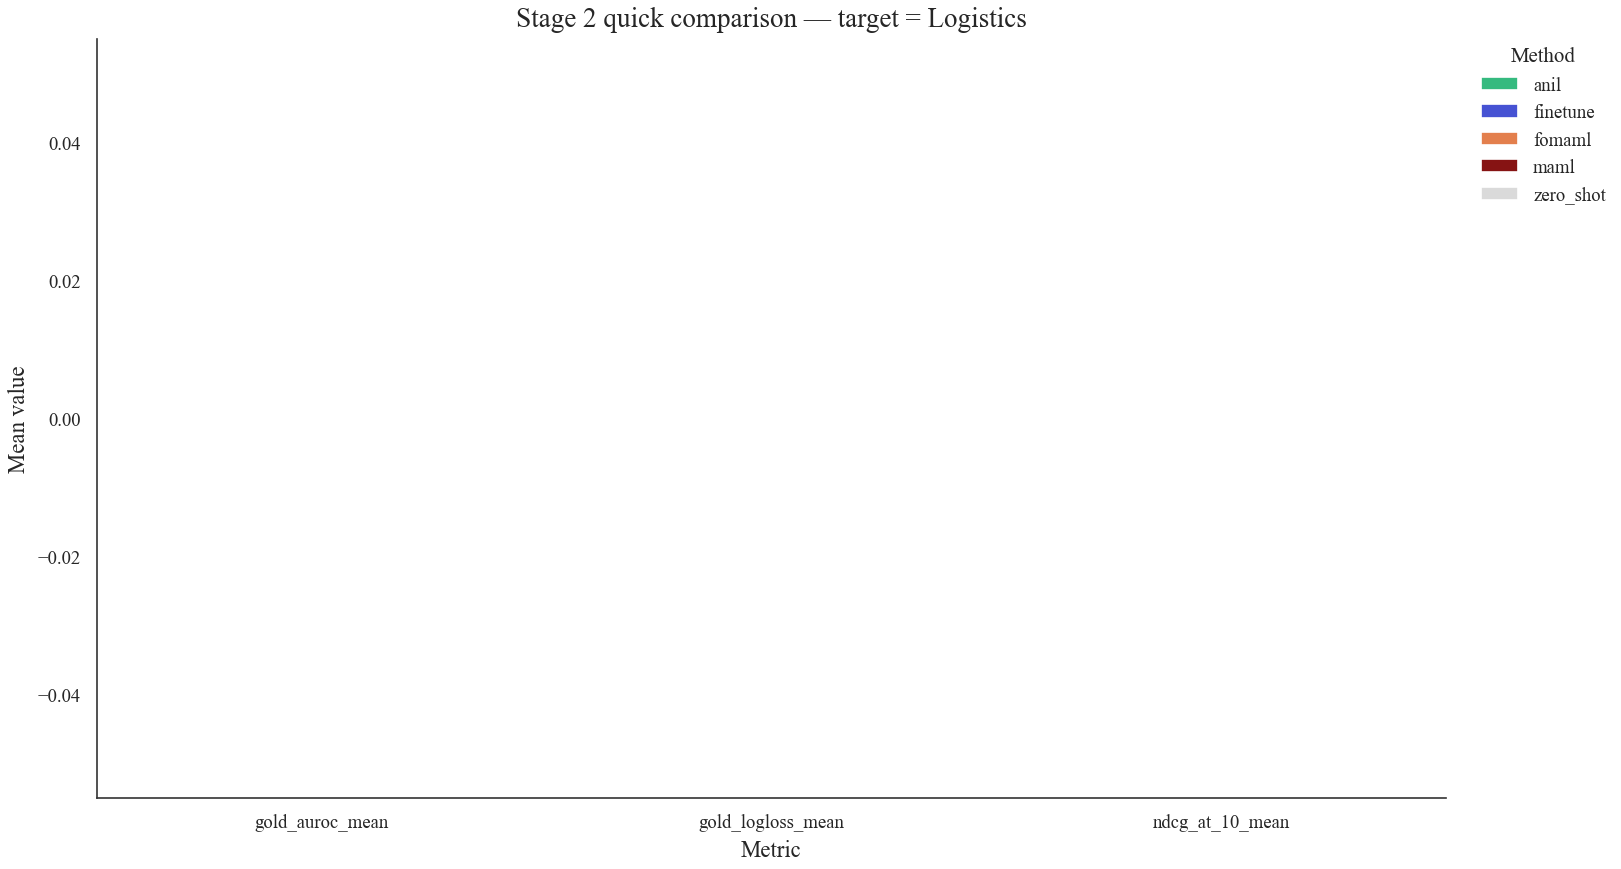

In [11]:
if not experiment_summary.empty:
    quick_df = experiment_summary.copy()
    target_dept = first_config["task_config"]["target_department"]
    if "target_department" in quick_df.columns:
        quick_df = quick_df[quick_df["target_department"] == target_dept].copy()

    metric_columns = [
        c for c in ["gold_auroc_mean", "gold_logloss_mean", "ndcg_at_10_mean"]
        if c in quick_df.columns
    ]
    if metric_columns and "method" in quick_df.columns:
        fig, ax = plot_stage2_metric_comparison(
            quick_df,
            metrics=metric_columns,
            group_col="method",
            title=f"Stage 2 quick comparison — target = {target_dept}",
        )
    else:
        display(quick_df.head(20))
else:
    print("No saved experiment results are available yet.")


## 13. Quick Summary Table

Compact tabular view of all experiments currently in the registry, sorted by
method and inner-step count. This is for rapid inspection only; thesis-ready
tables with confidence intervals and significance markers are in 17.1.


In [12]:
if not experiment_summary.empty:
    metric_cols = [c for c in experiment_summary.columns if c.endswith("_mean")]
    key_cols = [
        "experiment_id", "method", "init_name", "n_support_pos", "n_support_neg",
        "inner_steps", "target_department", "status", "n_metric_rows",
    ]
    display_cols = [c for c in key_cols if c in experiment_summary.columns] + metric_cols
    display_cols = list(dict.fromkeys(display_cols))  # deduplicate, preserve order

    quick_summary = experiment_summary[display_cols].copy()
    sort_by = [c for c in ["method", "init_name", "n_support_pos", "inner_steps"]
               if c in quick_summary.columns]
    if sort_by:
        quick_summary = quick_summary.sort_values(sort_by).reset_index(drop=True)
    display(quick_summary)
else:
    print("Run experiments first to populate the summary.")


,experiment_id,method,init_name,n_support_pos,n_support_neg,inner_steps,target_department,status,n_metric_rows,gold_auroc_mean,...,precision_at_10_mean,recall_at_10_mean,ndcg_at_10_mean,precision_at_20_mean,recall_at_20_mean,ndcg_at_20_mean,pred_mean_mean,pred_std_mean,frac_near_zero_mean,frac_near_one_mean
0,stage2__init-A_weak_only__method-anil__kpos-2_...,anil,A_weak_only,2,2,1,Logistics,failed,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,stage2__init-A_weak_only__method-anil__kpos-2_...,anil,A_weak_only,2,2,3,Logistics,failed,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,stage2__init-A_weak_only__method-anil__kpos-2_...,anil,A_weak_only,2,2,5,Logistics,failed,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,stage2__init-A_weak_only__method-finetune__kpo...,finetune,A_weak_only,2,2,1,Logistics,failed,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,stage2__init-A_weak_only__method-finetune__kpo...,finetune,A_weak_only,2,2,3,Logistics,failed,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,stage2__init-A_weak_only__method-finetune__kpo...,finetune,A_weak_only,2,2,5,Logistics,failed,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,stage2__init-A_weak_only__method-fomaml__kpos-...,fomaml,A_weak_only,2,2,1,Logistics,failed,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,stage2__init-A_weak_only__method-fomaml__kpos-...,fomaml,A_weak_only,2,2,3,Logistics,failed,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,stage2__init-A_weak_only__method-fomaml__kpos-...,fomaml,A_weak_only,2,2,5,Logistics,failed,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,stage2__init-A_weak_only__method-maml__kpos-2_...,maml,A_weak_only,2,2,1,Logistics,failed,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 14. Artifact Verification

Confirms that every expected output file is present for each cell in the
current batch. Missing `metrics.csv` or `predictions.csv` indicates a failed
run that should be re-executed with `FORCE_RERUN = True`. A missing
`history.csv` is expected for `zero_shot` (no outer-loop training) but is a
warning sign for adaptive methods.


In [13]:
artifact_names = [
    "resolved_config.yaml", "metrics.csv", "predictions.csv",
    "history.csv", "stage2_result_summary.json", "prediction_stats.csv",
]

artifact_rows = []
for exp_id, _ in experiment_list:
    exp_dir = EXPERIMENT_ROOT / exp_id
    row = {"experiment_id": exp_id}
    for name in artifact_names:
        row[name] = (exp_dir / name).exists()
    artifact_rows.append(row)

artifact_df = pd.DataFrame(artifact_rows)
display(artifact_df)


,experiment_id,resolved_config.yaml,metrics.csv,predictions.csv,history.csv,stage2_result_summary.json,prediction_stats.csv
0,stage2__init-A_weak_only__method-zero_shot__kp...,True,True,True,False,True,True
1,stage2__init-A_weak_only__method-zero_shot__kp...,True,True,True,False,True,True
2,stage2__init-A_weak_only__method-zero_shot__kp...,True,True,True,False,True,True
3,stage2__init-A_weak_only__method-finetune__kpo...,True,True,True,False,True,True
4,stage2__init-A_weak_only__method-finetune__kpo...,True,True,True,True,True,True
5,stage2__init-A_weak_only__method-finetune__kpo...,True,True,True,True,True,True
6,stage2__init-A_weak_only__method-anil__kpos-2_...,True,True,True,True,True,True
7,stage2__init-A_weak_only__method-anil__kpos-2_...,True,True,True,True,True,True
8,stage2__init-A_weak_only__method-anil__kpos-2_...,True,True,True,True,True,True
9,stage2__init-A_weak_only__method-fomaml__kpos-...,True,True,True,True,True,True
